# Standard / Reference Material Detection Final Demo

**Datamine CCLAS QC Anomaly Detection**

This notebook demonstrates the updated SRMS/reference-material detection workflow for CCLAS `STD` / Standard records. It uses the reusable production detector in `src.detectors.srms_detector`; detector logic is not duplicated in the notebook.


## Scope and QC-First Principle

Included: `STD` / Standard records only.

Excluded: BLK, SPK, REP, DUP, MSD, and UNK records.

Known CCLAS acceptance limits remain the primary QC decision layer. Historical statistics, Isolation Forest, and drift are supporting evidence and must not override or downgrade a known hard-limit failure.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "detectors" / "srms_detector.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.detectors import srms_detector as srms

CURRENT_TSV = PROJECT_ROOT / "data" / "TSV_LB26019534_I_0024367023.TSV"
if not CURRENT_TSV.exists():
    CURRENT_TSV = Path.home() / "Downloads" / "TSV_LB26019534_I_0024367023.TSV"
HISTORY_WORKBOOK = PROJECT_ROOT / "data" / "QC Anomaly Training Data v3.xlsx"
if not HISTORY_WORKBOOK.exists():
    HISTORY_WORKBOOK = Path.home() / "Downloads" / "QC Anomaly Training Data v3.xlsx"
CONFIG_PATH = PROJECT_ROOT / "config" / "srms_detector.yaml"

for path in [CURRENT_TSV, HISTORY_WORKBOOK, CONFIG_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## Active Configuration

The YAML file is the authoritative SRMS configuration. The historical worksheet and historical window size are loaded from config.


In [2]:
config = srms.load_srms_config(str(CONFIG_PATH))
config_table = pd.DataFrame([
    ("historical_sheet", config.historical_sheet),
    ("history_window_size", config.history_window_size),
    ("minimum_history", config.min_history),
    ("robust_z_threshold", config.robust_z_threshold),
    ("isolation_forest_min_history", config.min_iforest_history),
    ("isolation_forest_contamination", config.contamination),
    ("isolation_forest_estimators", config.n_estimators),
    ("drift_min_history", config.min_drift_history),
], columns=["Setting", "Value"])
display(config_table)
assert config.historical_sheet == "GO_FAA50V10 Asssessment"
assert config.history_window_size == 30


,Setting,Value
0,historical_sheet,GO_FAA50V10 Asssessment
1,history_window_size,30
2,minimum_history,5
3,robust_z_threshold,3.5
4,isolation_forest_min_history,20
5,isolation_forest_contamination,0.05
6,isolation_forest_estimators,250
7,drift_min_history,5


## Fields Available for Historical Matching

DataMine feedback requires matching on the strongest identity available: scheme, scheme version when present, analyte, unit, and Standard/reference-material fields. This workbook and TSV do not expose Scheme Version, so it is reported as unavailable rather than fabricated.


In [3]:
raw_history = srms.load_data(HISTORY_WORKBOOK, sheet_name=config.historical_sheet)
parsed = srms.parse_cclas_tsv(CURRENT_TSV)
std_records = srms.extract_cclas_standard_records(parsed)
historical = srms.prepare_historical_srms_baseline(HISTORY_WORKBOOK, config, sheet_name=config.historical_sheet)

field_table = pd.DataFrame([
    ["Standard code", "S_StandardCode", "STD_CODE", "Used"],
    ["Standard lot/material", "S_StandardLotCode", "STD_LOT_CODE", "Used"],
    ["Scheme code", "RSC_SchemeCode", "SCHEME_CODE", "Used"],
    ["Scheme version", "not present", "not present", "Unavailable; not fabricated"],
    ["Analyte code", "RSA_AnalyteCode", "ANALYTE_CODE", "Used"],
    ["Unit code", "SSA_UnitCode", "UNIT_CODE", "Used"],
    ["Specification code", "not present as identity", "SPECIFICATION_CODE", "Diagnostic only"],
], columns=["Identity field", "Current TSV field", "Historical workbook field", "Handling"])
display(field_table)
print(srms.describe_historical_matching_key(historical, std_records.iloc[0]))


,Identity field,Current TSV field,Historical workbook field,Handling
0,Standard code,S_StandardCode,STD_CODE,Used
1,Standard lot/material,S_StandardLotCode,STD_LOT_CODE,Used
2,Scheme code,RSC_SchemeCode,SCHEME_CODE,Used
3,Scheme version,not present,not present,Unavailable; not fabricated
4,Analyte code,RSA_AnalyteCode,ANALYTE_CODE,Used
5,Unit code,SSA_UnitCode,UNIT_CODE,Used
6,Specification code,not present as identity,SPECIFICATION_CODE,Diagnostic only


SRMSStandardCode + SRMSLotCode + SchemeCode + Analyte + UnitCode (SchemeVersion unavailable)


## Current Standard Observations

The current LabBatch contains four Standard records for this detector.


In [4]:
current_columns = ["SampleCode", "StandardCode", "StandardLotCode", "Scheme", "Analyte", "Unit", "Result", "Target", "LowerLimit", "LowerWarning", "UpperWarning", "UpperLimit", "CCLAS_StandardStatus"]
display(std_records[current_columns])
assert len(std_records) == 4


,SampleCode,StandardCode,StandardLotCode,Scheme,Analyte,Unit,Result,Target,LowerLimit,LowerWarning,UpperWarning,UpperLimit,CCLAS_StandardStatus
0,TSV_S0024366455,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,0.60,0.609,0.52307,0.554495,0.663505,0.69493,PASS
1,TSV_S0024366457,AUOP_06,AUOP_06,GO_FAA50V10,AU,MG_KG,1.00,5.691,5.09686,5.314256,6.067744,6.28514,LOWER_FAILURE
2,TSV_S0024366460,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,0.06,0.609,0.52307,0.554495,0.663505,0.69493,LOWER_FAILURE
3,TSV_S0024366462,AUOP_06,AUOP_06,GO_FAA50V10,AU,MG_KG,0.40,5.691,5.09686,5.314256,6.067744,6.28514,LOWER_FAILURE


## Historical Coverage and Duplicate Note

The original historical rows are retained. Exact duplicate rows are reported as a data-quality observation, not silently removed.


In [5]:
current_groups = std_records[["StandardCode", "StandardLotCode", "Scheme", "Analyte", "Unit"]].drop_duplicates()
coverage_rows = []
for row in current_groups.itertuples(index=False):
    mask = (
        raw_history["STD_CODE"].astype(str).eq(str(row.StandardCode))
        & raw_history["STD_LOT_CODE"].astype(str).eq(str(row.StandardLotCode))
        & raw_history["SCHEME_CODE"].astype(str).eq(str(row.Scheme))
        & raw_history["ANALYTE_CODE"].astype(str).eq(str(row.Analyte))
        & raw_history["UNIT_CODE"].astype(str).eq(str(row.Unit))
    )
    group = raw_history.loc[mask]
    dup_subset = ["STD_CODE", "STD_LOT_CODE", "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE", "JOB_CODE", "NUMERIC_FINAL_VALUE", "ANALYSED_DATE"]
    dup_mask = group.duplicated(subset=dup_subset, keep=False)
    coverage_rows.append({
        "StandardCode": row.StandardCode,
        "StandardLotCode": row.StandardLotCode,
        "Scheme": row.Scheme,
        "Analyte": row.Analyte,
        "Unit": row.Unit,
        "TotalRowsBeforeWindow": len(group),
        "FirstDate": group["ANALYSED_DATE"].min(),
        "LastDate": group["ANALYSED_DATE"].max(),
        "DuplicateRows": int(dup_mask.sum()),
        "DuplicateGroups": int(group.loc[dup_mask, dup_subset].drop_duplicates().shape[0]),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage)
assert dict(zip(coverage["StandardCode"], coverage["TotalRowsBeforeWindow"])) == {"OXE113": 301, "AUOP_06": 622}


,StandardCode,StandardLotCode,Scheme,Analyte,Unit,TotalRowsBeforeWindow,FirstDate,LastDate,DuplicateRows,DuplicateGroups
0,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,301,2018-05-03 09:08:43,2025-11-26 10:38:42,6,3
1,AUOP_06,AUOP_06,GO_FAA50V10,AU,MG_KG,622,2019-05-27 14:08:51,2022-09-06 13:40:31,0,0


## Run Production Detector

The historical baseline now uses the latest 30 matching prior observations. `TotalMatchingHistory` reports all prior matching observations available; `HistoryWindowUsed` reports the selected recent baseline size.


In [6]:
results, status_summary, risk_summary = srms.run_cclas_standard_pipeline(
    str(CURRENT_TSV),
    config,
    history_path=str(HISTORY_WORKBOOK),
    sheet_name=config.historical_sheet,
)
results = srms.order_cclas_standard_columns(results)

display(status_summary.sort_values("Limit_Status"))
display(risk_summary.sort_values("Final_Risk"))


,Limit_Status,Count
0,FAIL,3
1,PASS,1


,Final_Risk,Count
0,Critical,3
1,Low,1


## Historical Window, Robust Z, Isolation Forest, Drift, and Final Risk

The statistics below are calculated from the recent matching historical window, not the full historical group.


In [7]:
result_columns = [
    "SampleCode", "StandardCode", "StandardLotCode", "Scheme", "Analyte", "Unit",
    "TotalMatchingHistory", "HistoryWindowUsed", "HistoricalMedian", "HistoricalMAD", "RobustZScore",
    "Historical_Status", "IsolationForestScore", "IsolationForestStatus", "IsolationForestAnomaly",
    "DriftFlag", "Limit_Status", "Final_Risk", "CCLAS_StandardStatus", "CCLAS_Mismatch",
]
display(results[result_columns])
assert results["Limit_Status"].value_counts().to_dict() == {"FAIL": 3, "PASS": 1}
assert results["Final_Risk"].value_counts().to_dict() == {"Critical": 3, "Low": 1}
assert int(results["CCLAS_Mismatch"].sum()) == 0


,SampleCode,StandardCode,StandardLotCode,Scheme,Analyte,Unit,TotalMatchingHistory,HistoryWindowUsed,HistoricalMedian,HistoricalMAD,RobustZScore,Historical_Status,IsolationForestScore,IsolationForestStatus,IsolationForestAnomaly,DriftFlag,Limit_Status,Final_Risk,CCLAS_StandardStatus,CCLAS_Mismatch
0,TSV_S0024366455,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,301,30,0.609690,0.014049,-0.465225,PASS,0.441183,PASS,False,False,PASS,Low,PASS,False
1,TSV_S0024366457,AUOP_06,AUOP_06,GO_FAA50V10,AU,MG_KG,622,30,5.629902,0.087752,-35.587321,WARNING,0.743829,WARNING,True,False,FAIL,Critical,LOWER_FAILURE,False
2,TSV_S0024366460,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,301,30,0.609690,0.014049,-26.391683,WARNING,0.559483,PASS,False,False,FAIL,Critical,LOWER_FAILURE,False
3,TSV_S0024366462,AUOP_06,AUOP_06,GO_FAA50V10,AU,MG_KG,622,30,5.629902,0.087752,-40.199167,WARNING,0.744522,WARNING,True,False,FAIL,Critical,LOWER_FAILURE,False


## Recent Historical Window Plot

The plot highlights the latest 30 matching historical observations used for the baseline and the current observation being scored.


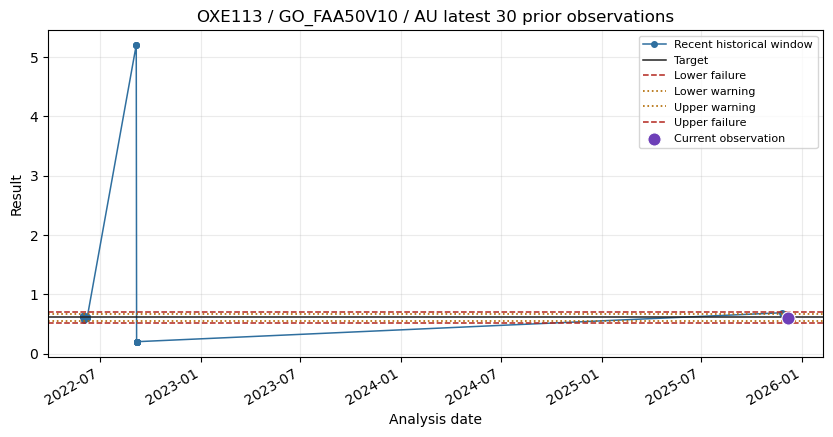

In [8]:
def plot_recent_window(sample_code):
    current = results.loc[results["SampleCode"].eq(sample_code)].iloc[0]
    group = srms.matching_historical_group(historical, current, window_size=config.history_window_size)
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(group["AnalysisDate"], group["Value"], marker="o", linewidth=1.1, markersize=4, color="#2f6f9f", label="Recent historical window")
    ax.axhline(current["Target"], color="#222222", linestyle="-", linewidth=1.1, label="Target")
    ax.axhline(current["LowerLimit"], color="#b3261e", linestyle="--", linewidth=1.1, label="Lower failure")
    ax.axhline(current["LowerWarning"], color="#b26a00", linestyle=":", linewidth=1.2, label="Lower warning")
    ax.axhline(current["UpperWarning"], color="#b26a00", linestyle=":", linewidth=1.2, label="Upper warning")
    ax.axhline(current["UpperLimit"], color="#b3261e", linestyle="--", linewidth=1.1, label="Upper failure")
    current_x = group["AnalysisDate"].max() + pd.Timedelta(days=10)
    ax.scatter([current_x], [current["Result"]], s=90, color="#6d3fb8", edgecolor="white", linewidth=0.8, zorder=5, label="Current observation")
    ax.set_title(f"{current['StandardCode']} / {current['Scheme']} / {current['Analyte']} latest {config.history_window_size} prior observations")
    ax.set_xlabel("Analysis date")
    ax.set_ylabel("Result")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    fig.autofmt_xdate()
    plt.show()

plot_recent_window("TSV_S0024366455")


## Historical Back-Testing Summary

Back-testing treats each historical observation at time `t` as the current observation, then uses only matching observations before `t`, restricted to the configured 30-observation window. `STANDARD_STATUS` is used only after prediction for validation/comparison.


In [9]:
backtest = srms.run_historical_backtest(raw_history, config)
backtest_summary = srms.create_backtest_summary(backtest, config)
display(backtest_summary)

backtest_display = backtest[[
    "SampleID", "SRMSStandardCode", "SRMSLotCode", "SchemeCode", "Analyte", "UnitCode",
    "AnalysisDate", "Value", "TotalMatchingHistory", "HistoryWindowUsed", "HistoricalMedian",
    "HistoricalMAD", "RobustZScore", "LimitStatus", "FinalRiskLevel", "StandardStatus",
]].tail(10)
display(backtest_display)


,Metric,Value
0,Rows,9636
1,Sufficient history,9349
2,Insufficient history,287
3,Limit FAIL,403
4,Robust Z warnings,416
5,Isolation Forest anomalies,431
6,Drift flags,351
7,Rows with CCLAS status,9635
8,Limit/CCLAS mismatches,91


,SampleID,SRMSStandardCode,SRMSLotCode,SchemeCode,Analyte,UnitCode,AnalysisDate,Value,TotalMatchingHistory,HistoryWindowUsed,HistoricalMedian,HistoricalMAD,RobustZScore,LimitStatus,FinalRiskLevel,StandardStatus
9626,TSV_JB0024248574-22446,OXN117,OXN117,GO_FAA50V10,AU,MG_KG,2022-09-06 13:06:48,0.200,1057,30,7.566235,0.119810,-41.470152,FAIL,Critical,LowerFailure
9627,TSV_JB0024248574-22447,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,2022-09-06 13:06:48,0.200,297,30,0.611566,0.007911,-35.089294,FAIL,Critical,LowerFailure
9628,TSV_JB0024249397-22434,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,298,30,0.609690,0.009577,-28.854297,FAIL,Critical,IgnoredLowerFailure
9629,TSV_JB0024249397-22435,SF_100,SF_100,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,213,30,0.860699,0.011724,-38.010864,FAIL,Critical,IgnoredLowerFailure
9630,TSV_JB0024249397-22436,AUOP_06,AUOP_06,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,621,30,5.629902,0.082751,-44.258954,FAIL,Critical,IgnoredLowerFailure
9631,TSV_JB0024249397-22437,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,299,30,0.609690,0.009787,-28.234595,FAIL,Critical,IgnoredLowerFailure
9632,TSV_JB0024249397-22438,OXQ90,OXQ90,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,376,30,24.373341,0.943720,-17.277289,FAIL,Critical,IgnoredLowerFailure
9633,TSV_JB0024249397-22439,OXQ90,OXQ90,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,377,30,24.373341,1.105861,-14.744099,FAIL,Critical,IgnoredLowerFailure
9634,TSV_JB0024249397-22440,OXN117,OXN117,GO_FAA50V10,AU,MG_KG,2022-09-06 13:40:31,0.200,1058,30,7.549481,0.136564,-36.299699,FAIL,Critical,IgnoredLowerFailure
9635,TSV_LB0024365452-22433,OXE113,OXE113,GO_FAA50V10,AU,MG_KG,2025-11-26 10:38:42,0.688,300,30,0.609690,0.011740,4.499250,WARNING,High,UpperWarning


## Final Checks

- Matching uses Standard code, Standard lot/material, Scheme code, Analyte, and Unit.
- Scheme Version is not present in the supplied current TSV or GO historical worksheet, so it is not fabricated.
- Historical statistics, Isolation Forest, and drift use prior observations only.
- Known hard-limit failures remain Critical.
- CCLAS Standard Status remains validation-only.
